This notebook gives an example of using CONDOR to find strong P/R forecasts and job type weight W values for a given data center configuration.

First, we import the appropriate packages and methods. 

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
from aqa_parsing_utilities import *
from data_center_model import *
from inference_scripts import *
from sklearn.preprocessing import normalize
import matplotlib as mpl
import time

mpl.rcParams['figure.dpi'] = 100


To load our model, we just use PyTorch's loader. We include a well-trained model as part of our repository. 

In [2]:
# Loads model using Pytorch
# map_location='cpu' is needed because the model was saved on a GPU machine
# weights_only=False is needed for PyTorch 2.0+ compatibility with older .pth files
sim_model = torch.load('models/model_v2_1.pth', map_location='cpu', weights_only=False)


Now we define our data center configuration. Our network was trained over the following modifiable parameters:
- P: The average power the data center expects to use in the upcoming hour. 
- R: The reserve power the data center expects to be able to offer the power provider. This reserve is "residual" from the average power - so if the average power is 10 kW and the reserve power is 1 kW, the data center should have the capacity to use between 9 and 11 kW as the power provider requests. 
- Workload: The workload mix for the data center's upcoming operation, which can include an arbitrarily long mix of job types. We include a fixed, pre-defined set of workload mixes for this work, but you can 
- Utilization: the target for how many of the servers in the data center should be used, on average. This is a ratio out of 1: so values like 0.9 represent high utilization, 0.5 represents low. Lower utilization allows for higher reserve because flexibility is increased. 
- Data Center Size: the number of servers in our data center. 

Because the goal of CONDOR is to optimize P and R, we usually set them to a fixed initialization. 

In [3]:
# Defines our data center configuration. 
p_init = 1.0
r_init = 0.4
workload = 'W7'
util = 0.8
data_center_size = 500

Lastly, we set some hyperparameters for our optimization problem:
- Cost Weights: These are how each of the three components of the cost function are weighed. They are the power cost (penalizes high purchasing costs), the tracking error cost (penalizes not complying with the power provider signal), and QoS cost (penalizes when QoS is not met). See full paper for more details. We give a set of values that usually work reasonably well, but more tuning often helps for individual job types. 
- LR: the learning rate for the gradient descent optimization. We use vanilla GD with no other tricks (like momentum, per-parameter updates, etc.). We find 1e-2 usually works well.
- Iterations: the number of GD iterations performed. We set this to 150 for testing parity for paper experiments, but to increase the chance of convergence increase this.

In [4]:
# Defines our optimization hyper-parameters.
cost_weights = [0.05, 0.7, 2.0]
lr = 1e-2
iterations = 150

To run the optimization process, we use the model_pr_descent method. This takes as argument our data center model and data center configuration, and returns the following:
- P Record: an array with the P value at each gradient-descent iteration.
- R Record: an array with the R value at each gradient-descent iteration.
- W Record: a nested array with the W values at each gradient-descent iteration. The number of elements each value of the outside array has depends on the size of the workload mix; ie, if the workload mix has 3 jobs, each element will have 3 values for the weight of each job. 
- PGR: an array with the record of the gradient of P with respect to the cost at each GD iteration.
- RGR: an array with the record of the gradient of R with respect to the cost at each GD iteration.
- WGR: a nested array with the record of the gradient of W with respect to the cost at each GD iteration. See explanation of W record for shape. 
- Cost Record: an array with the record of the cost at each GD iteration. 

Note - all of these arrays are Numpy arrays. 

In [5]:
# does GD optimization process
now = time.time()
P_record, R_record,W_record,PGR,RGR,WGR, cost_record = model_pr_descent(p_init, 
                                                                       r_init, 
                                                                       workload, 
                                                                       sim_model,
                                                                       cost_weights = cost_weights,
                                                                       client_count = data_center_size,
                                                                       util = util,
                                                                       lr=lr,
                                                                       iterations=iterations)
print('Time:',time.time()-now)

# To print our final P/R/W values, we just take the last element of the record arrays:
print('Final P:', P_record[-1])
print('Final R:', R_record[-1])
print('Final P:', W_record[-1])

Time: 1.9024348258972168
Final P: 1.140529990196228
Final R: 0.638457179069519
Final P: [0.01749408 0.02529996 0.01843653 0.01909324 0.15909691 0.01733931
 0.01739017 0.01695613 0.0157078  0.01490028 0.03995497 0.273724
 0.01785134 0.01490312 0.01644359 0.3154086 ]


To help visualize the results, you can run the following cells to plot the optimization process.

1.140529990196228 0.638457179069519 -4.664069652557373


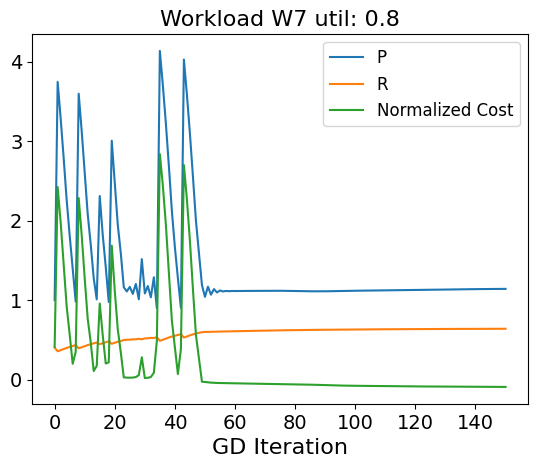

In [6]:
plt.plot(range(len(P_record)),P_record,label='P')
plt.plot(range(len(R_record)),R_record,label='R')
plt.plot(range(len(cost_record)),cost_record/50,label='Normalized Cost')
plt.xlabel('GD Iteration', fontsize=16)
plt.legend(fontsize=12)
plt.title('Workload ' + workload + ' util: ' + str(util), fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(0, 2.25)
print(P_record[-1],R_record[-1],cost_record[-1])

1.140529990196228 0.638457179069519 -4.664069652557373


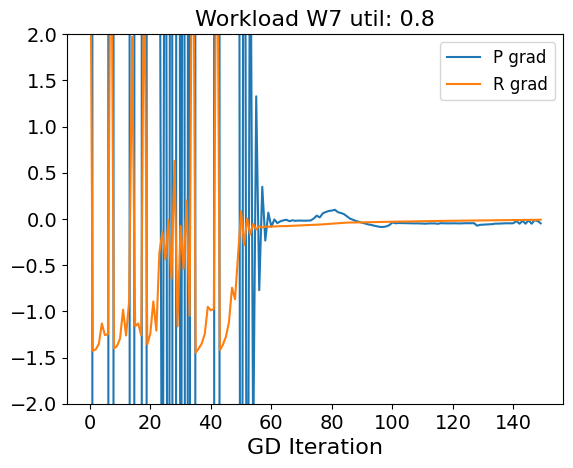

In [7]:
plt.plot(range(len(PGR)),PGR,label='P grad')
plt.plot(range(len(RGR)),RGR,label='R grad')
#plt.plot(range(len(cost_record)),cost_record,label='Normalized Cost')
plt.xlabel('GD Iteration', fontsize=16)
plt.legend(fontsize=12)
plt.title('Workload ' + workload + ' util: ' + str(util), fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(-2,2)

print(P_record[-1],R_record[-1],cost_record[-1])

In [8]:
print(W_record.shape)

(151, 16)


[0.01749408 0.02529996 0.01843653 0.01909324 0.15909691 0.01733931
 0.01739017 0.01695613 0.0157078  0.01490028 0.03995497 0.273724
 0.01785134 0.01490312 0.01644359 0.3154086 ]


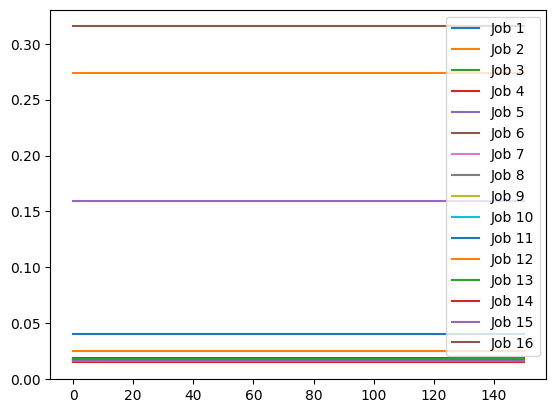

In [9]:
for i in range(len(W_record[0])):
    plt.plot(range(len(W_record[:,i])),W_record[:,i],label='Job '+str(i+1))
plt.legend()
print(W_record[-1,:])

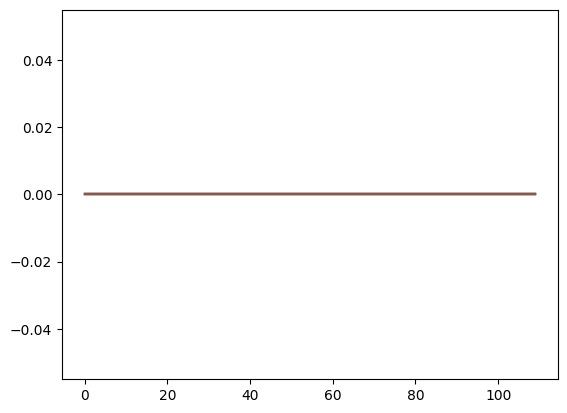

In [10]:
starting_index = 40
for i in range(len(W_record[0])):
    plt.plot(range(len(WGR[starting_index:,i])),WGR[starting_index:,i])

In [12]:
print(W_record[0])

[0.01749408 0.02529996 0.01843653 0.01909324 0.15909691 0.01733931
 0.01739017 0.01695613 0.0157078  0.01490028 0.03995497 0.273724
 0.01785134 0.01490312 0.01644359 0.3154086 ]


---
## Cost Function Surface — 3D Surface Plot Exploration

CONDOR's neural network learns all three cost components separately. By scanning a grid of P̄ and R values and running a single forward pass at each point, we can visualize the **3D cost landscape** the optimizer is navigating — matching the style of Figure 4 in the paper.

### What each component penalizes:

**C_Power** — the raw energy purchasing cost.  
Formula: `C_Power = P̄ - Π_R * R`  
Conceptually: a higher average power bid means buying more electricity (expensive). A higher reserve R earns back money because the grid *pays you* for offering flexibility. The surface should look like a **tilted ramp** — sloping upward as P increases, downward as R increases. Nearly linear, because the underlying formula is arithmetic.

**C_Error** — the regulation tracking error.  
Formula: `C_Error = E[|P(t) - P_target(t)|]`  
Conceptually: the grid constantly sends signals asking the data center to modulate power up/down within the reserve band. If R is too small (no room to modulate) or P is set inconsistently with the workload's actual capabilities, the data center can't follow those signals. Expect a **valley shape** — low in the feasible middle region, rising at extremes.

**C_QoS** — the quality-of-service violation cost.  
Formula: `C_QoS = β Σ_j SoftPlus(ρ(Prob[Q^j - Q^j_thres] - δ^j))`  
Conceptually: when P is too low, servers are power-capped → jobs slow down → deadlines missed → penalty fires. The SoftPlus creates a **soft cliff** on the low-P side: nearly flat once P is high enough for jobs to run freely, steeply rising as P drops below the threshold. This term (weight 2.0) dominates the total cost and is the main force pushing the optimizer toward higher P.

The **red stem + point** marks the GD-optimal (P̄, R) found earlier — it should sit in the low-cost basin of the landscape.

In [11]:
# ── Grid scan: run a single model forward pass at every (P, R) point ──────────
# We fix the workload, utilization, and server count, then sweep P and R
# to see how each cost component responds.

# Reload workload in the same format that the model expects
work_feature_dict = get_workload_mix_features_dict('../data/')
wl_mix_arr = work_feature_dict[workload]           # shape: (n_jobs, 6)  [already normalized]
wl_size    = len(wl_mix_arr)
wl_weights = np.ones(wl_size) / wl_size           # uniform weights (same as GD initialization)
wl_combined = np.concatenate((wl_mix_arr, np.array([wl_weights]).T), axis=1)  # (n_jobs, 7)
wl_tensor   = torch.tensor(wl_combined).unsqueeze(0).float()                  # (1, n_jobs, 7)

# Define the P and R ranges to scan
# These are normalized values — the GD run above converged inside this window.
# P ~0.5 to 2.0 covers low-power (risky for QoS) to high-power (expensive) regimes.
# R ~0.0 to 1.2 covers no-reserve to high-reserve.
n_points = 40
p_range = np.linspace(0.4, 2.0, n_points)
r_range = np.linspace(0.0, 1.2, n_points)
P_grid, R_grid = np.meshgrid(p_range, r_range)

C_power_grid = np.zeros_like(P_grid)
C_error_grid = np.zeros_like(P_grid)
C_qos_grid   = np.zeros_like(P_grid)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
sim_model.eval()
wl_tensor = wl_tensor.to(device)

with torch.no_grad():
    for i, p in enumerate(p_range):
        for j, r in enumerate(r_range):
            sim_cfg = torch.tensor(
                [p, r, float(data_center_size), util, float(wl_size)]
            ).float().to(device)
            out = sim_model(sim_cfg, wl_tensor)
            C_power_grid[j, i] = out[0].item()
            C_error_grid[j, i] = out[1].item()
            C_qos_grid[j, i]   = out[2].item()

# Compute weighted total cost using the same cost_weights as the GD run
C_total_grid = (cost_weights[0] * C_power_grid +
                cost_weights[1] * C_error_grid +
                cost_weights[2] * C_qos_grid)

print("Grid scan complete.")
print(f"  C_Power range : [{C_power_grid.min():.3f},  {C_power_grid.max():.3f}]")
print(f"  C_Error range : [{C_error_grid.min():.3f},  {C_error_grid.max():.3f}]")
print(f"  C_QoS  range  : [{C_qos_grid.min():.3f},  {C_qos_grid.max():.3f}]")
print(f"  C_Total range : [{C_total_grid.min():.3f},  {C_total_grid.max():.3f}]")


Grid scan complete.
  C_Power range : [3.119,  24.554]
  C_Error range : [3.743,  49.380]
  C_QoS  range  : [-2.683,  52.442]
  C_Total range : [5.338,  112.605]


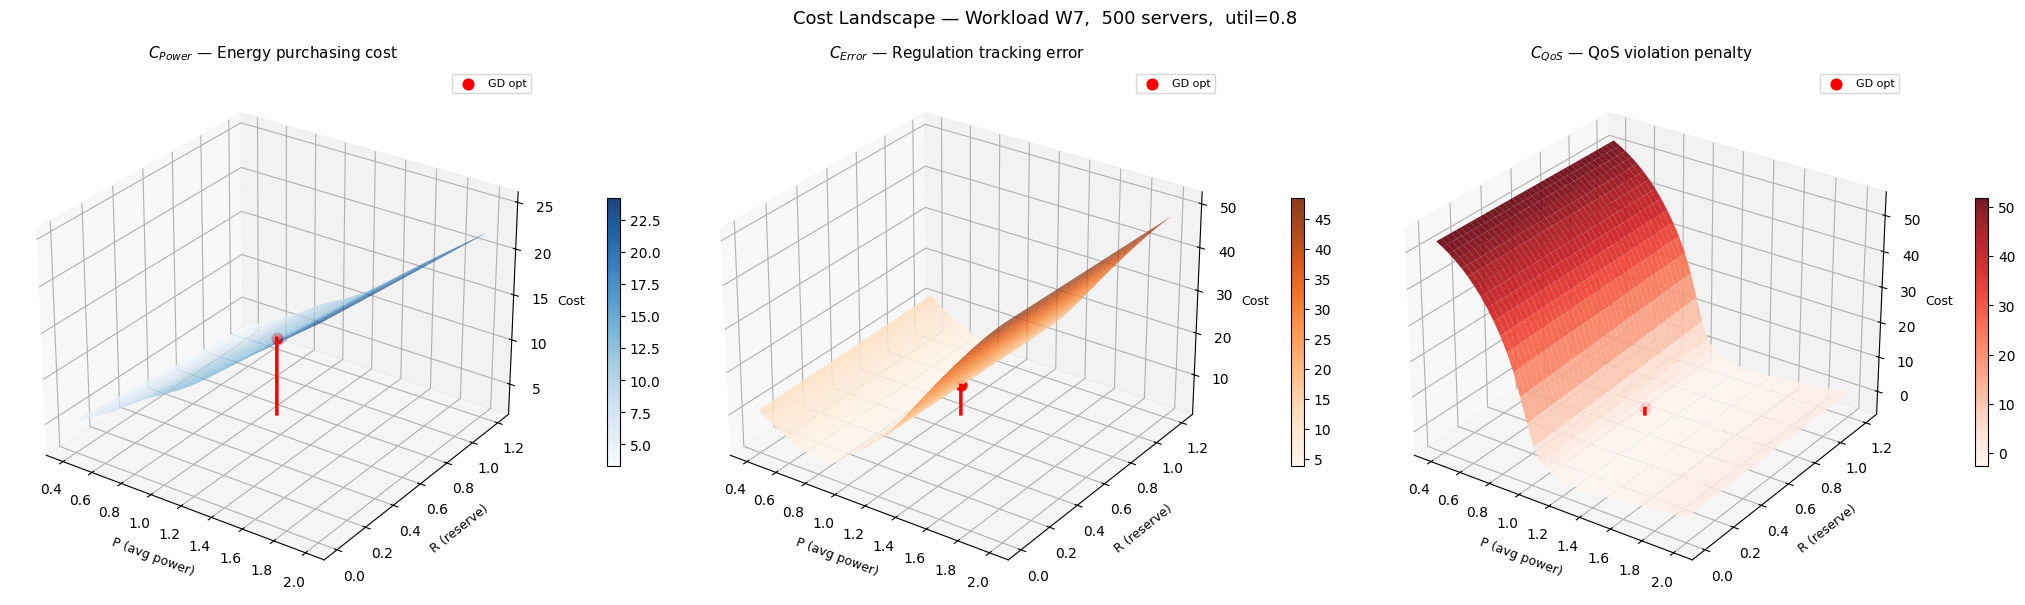

In [12]:
# ── 3D surface plots for the three individual cost components (like Figure 4 in the paper) ──
from mpl_toolkits.mplot3d import Axes3D  # registers the 3D projection

titles = [
    '$C_{Power}$ — Energy purchasing cost',
    '$C_{Error}$ — Regulation tracking error',
    '$C_{QoS}$ — QoS violation penalty',
]
grids = [C_power_grid, C_error_grid, C_qos_grid]
cmaps = ['Blues', 'Oranges', 'Reds']

# The GD-optimized values found earlier
p_opt = P_record[-1]
r_opt = R_record[-1]

fig = plt.figure(figsize=(21, 6))

for idx, (title, grid, cmap) in enumerate(zip(titles, grids, cmaps)):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')

    # Main 3D surface — color encodes height, same style as Figure 4
    surf = ax.plot_surface(P_grid, R_grid, grid, cmap=cmap, edgecolor='none', alpha=0.9)
    fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)

    # Red vertical stem at the GD-optimal (P, R) so you can see exactly
    # where the optimizer landed on this cost landscape
    z_base = grid.min()
    z_top  = grid[np.argmin(np.abs(r_range - r_opt)), np.argmin(np.abs(p_range - p_opt))]
    ax.plot([p_opt, p_opt], [r_opt, r_opt], [z_base, z_top],
            color='red', linewidth=2.5, zorder=10)
    ax.scatter([p_opt], [r_opt], [z_top], color='red', s=60, zorder=11, label='GD opt')

    ax.set_xlabel('P (avg power)', fontsize=9, labelpad=6)
    ax.set_ylabel('R (reserve)',   fontsize=9, labelpad=6)
    ax.set_zlabel('Cost',          fontsize=9, labelpad=4)
    ax.set_title(title, fontsize=11, pad=8)
    ax.legend(fontsize=8)
    ax.view_init(elev=28, azim=-55)  # same viewing angle as Figure 4 in the paper

plt.suptitle(
    f'Cost Landscape — Workload {workload},  {data_center_size} servers,  util={util}',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()


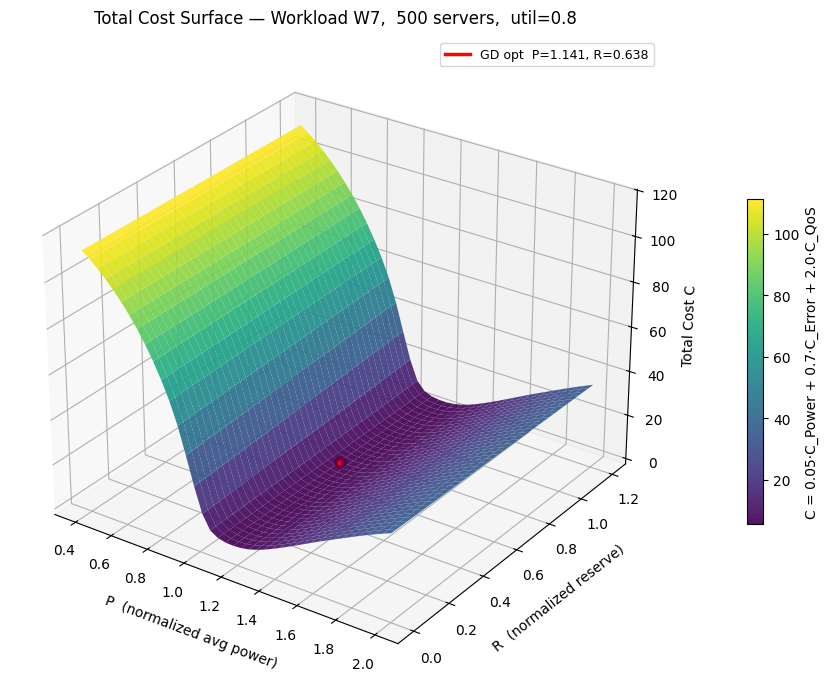


GD solution:  P = 1.1405,  R = 0.6385
Cost at GD solution : 5.8279
Minimum cost in grid: 5.3379  at P=1.221, R=1.200


In [13]:
# ── 3D surface of the total weighted cost C ───────────────────────────────────
# C = 0.05·C_Power + 0.7·C_Error + 2.0·C_QoS
# This is the combined landscape the GD optimizer was descending.
# The red stem should sit in the lowest basin — confirming GD found a good solution.
fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(P_grid, R_grid, C_total_grid, cmap='viridis', edgecolor='none', alpha=0.92)
fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1,
             label='C = 0.05·C_Power + 0.7·C_Error + 2.0·C_QoS')

# Vertical stem marking the GD solution
z_base = C_total_grid.min()
z_top  = C_total_grid[np.argmin(np.abs(r_range - r_opt)), np.argmin(np.abs(p_range - p_opt))]
ax.plot([p_opt, p_opt], [r_opt, r_opt], [z_base, z_top],
        color='red', linewidth=2.5, zorder=10, label=f'GD opt  P={p_opt:.3f}, R={r_opt:.3f}')
ax.scatter([p_opt], [r_opt], [z_top], color='red', s=70, zorder=11)

ax.set_xlabel('P  (normalized avg power)', fontsize=10, labelpad=8)
ax.set_ylabel('R  (normalized reserve)',   fontsize=10, labelpad=8)
ax.set_zlabel('Total Cost C',              fontsize=10, labelpad=4)
ax.set_title(
    f'Total Cost Surface — Workload {workload},  {data_center_size} servers,  util={util}',
    fontsize=12, pad=10
)
ax.legend(fontsize=9)
ax.view_init(elev=28, azim=-55)
plt.tight_layout()
plt.show()

print(f"\nGD solution:  P = {p_opt:.4f},  R = {r_opt:.4f}")
print(f"Cost at GD solution : {z_top:.4f}")
print(f"Minimum cost in grid: {C_total_grid.min():.4f}  at P={p_range[np.unravel_index(C_total_grid.argmin(), C_total_grid.shape)[1]]:.3f}, R={r_range[np.unravel_index(C_total_grid.argmin(), C_total_grid.shape)[0]]:.3f}")
